In [61]:
using BSON: @load
using DriftDiffusionModels
using HiddenMarkovModels
using MultivariateStats
using Clustering
using DataFrames
using Distances
using StatsBase
using StatsPlots
using Plots

In [11]:
using BSON: @load
using DriftDiffusionModels
using Plots

# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

In [152]:
ddm_params = Matrix{Float64}(undef, 4, 18 * 4) # 4 parameters per DDM, (18 subjects x 4 states)

for (i, fit) in enumerate(ddmhmm_fits)
    for k in 1:4
        ddm = fit.hmm.dists[k]
        ddm_params[:, (i - 1) * 4 + k] = [ddm.v, ddm.B, ddm.a₀, ddm.τ]
    end
end

ddm_params_df = DataFrame(ddm_params', [:v, :B, :a0, :tau])
animal_files = [split(fname, "\\")[end] for fname in bson_files]
animal_name  = [split(file, "_")[1] for file in animal_files]

ddm_params_df.rat = repeat(animal_name, inner=4);

ddm_params_clean = Matrix(select(ddm_params_df, Not(:rat))) # for numerical analyses

# standardize first if need later
zscore(x; dims) = (x .- mean(x; dims=dims)) ./ std(x; dims=dims)
ddm_params_z = zscore(ddm_params_clean'; dims=2)

4×72 Matrix{Float64}:
  0.0884106   0.0123428  -0.159011  …  -0.623018    -0.135475   -0.299235
 -0.329032   -0.153295   -0.494668      0.00684298  -0.333599   -0.473151
 -1.05581    -0.630828   -0.70414      -0.186832    -0.236163    0.290069
  0.833301    1.09977     0.424557     -2.15416     -0.0134415  -0.466619

In [188]:
ddm_params_df

Row,v,B,a0,tau,rat
,Float64,Float64,Float64,Float64,SubStrin…
1,0.800873,1.47002,0.292321,0.754848,1029
2,0.725818,1.8118,0.358132,0.822089,1029
3,0.556746,1.14789,0.346779,0.651706,1029
4,0.612275,1.69357,0.302977,0.518806,1029
5,0.727369,1.52206,0.519774,0.44123,1052
6,0.845505,1.81247,0.379647,0.682955,1052
7,0.661512,2.44532,0.792997,0.698185,1052
8,0.891777,1.46226,0.536375,0.573163,1052
9,0.221718,1.8506,0.167597,0.0790191,1054


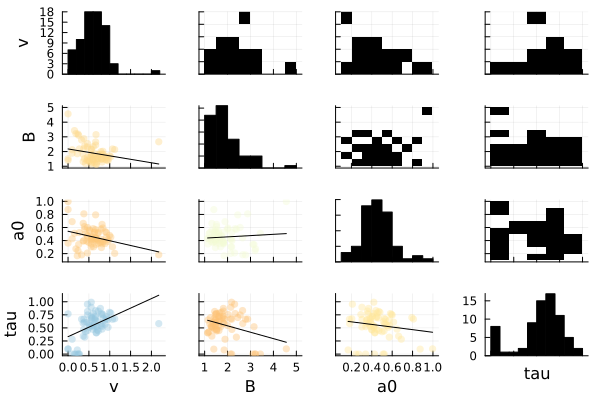

In [191]:
ddm_params_df

@df ddm_params_df[Not(37), :] corrplot(cols(1:4))

In [180]:
function parallel_analysis(X; n_iter=500)
    n, p = size(X)
    R = cor(X)
    eig_real = sort(eigvals(R); rev=true)

    eig_rand = zeros(n_iter, p)
    for i in 1:n_iter
        Xr = randn(n, p)
        eig_rand[i, :] = sort(eigvals(cor(Xr)); rev=true)
    end

    eig_mean = mean(eig_rand, dims=1)
    eig_95 = mapslices(x -> quantile(x, 0.95), eig_rand; dims=1)

    return eig_real, eig_mean[:], eig_95[:]
end

eig_real, eig_mean, eig_95 = parallel_analysis(ddm_params_z'[Not(37), :])

([1.832205717159037, 0.9538377605678167, 0.7291882748721973, 0.48476824740095004], [1.2656602147624145, 1.0701896240871558, 0.9174350635985458, 0.7467150975518839], [1.4089900383006462, 1.1579964028487377, 0.9960921924983341, 0.8646911580637302])

In [183]:
# Fit 2-factor FA model
fa = fit(FactorAnalysis, ddm_params_z[:, Not(37)]; maxoutdim=1)

# scores = predict(fa, ddm_params_z)'  # size: nrows × 2
# scatter(scores[:, 1], scores[:, 2]; group=ddm_params_df.rat, legend=false,
#     xlabel="Factor 1", ylabel="Factor 2", title="Factor Analysis of DDM Parameters")

Factor Analysis(indim = 4, outdim = 1)

In [174]:
out = argmax(scores)
println(out)

CartesianIndex(37, 1)


In [177]:
scores[37, :]

2-element Vector{Float64}:
 7.967807673186441
 1.6909414719940505

In [184]:
fa.W

4×1 Matrix{Float64}:
  0.2403873240884616
 -0.12700106418172602
 -0.33326456424828443
  0.6500700592231119